In [17]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from particle_nn_sim.simulator import ParticleSim2D
from particle_nn_sim.data import collect_episodes, episodes_to_XY_residual
from particle_nn_sim.train import fit_standardizer, apply_standardizer, StepDataset, train
from particle_nn_sim.models import MLP
from particle_nn_sim.rollout_eval import nn_rollout_residual, plot_rollout_error, animate_side_by_side, rms_pos_error
from particle_nn_sim.models import ResMLP
from torch.utils.data import WeightedRandomSampler


In [19]:
# --- simulator setup ---
sim = ParticleSim2D(W=1.0, H=1.0, radii=[0.06, 0.06], masses=[1.0, 1.0], restitution=1.0, seed=1)

# --- data ---
pos_all, vel_all, coll_all, meta = collect_episodes(sim, E=100, steps=10000, dt=0.01, speed_max=0.7, seed=0)
E = pos_all.shape[0]
idx = np.arange(E)
n_train = int(0.8 * E)
train_eps = idx[:n_train]
test_eps  = idx[n_train:]

Xtr, Ytr, Ctr = episodes_to_XY_residual(pos_all, vel_all, coll_all, meta, train_eps)
Xte, Yte, Cte = episodes_to_XY_residual(pos_all, vel_all, coll_all, meta, test_eps)

# --- normalize ---
x_mean, x_std = fit_standardizer(Xtr)
y_mean, y_std = fit_standardizer(Ytr)

Xtr_n = apply_standardizer(Xtr, x_mean, x_std)
Ytr_n = apply_standardizer(Ytr, y_mean, y_std)
Xte_n = apply_standardizer(Xte, x_mean, x_std)
Yte_n = apply_standardizer(Yte, y_mean, y_std)

# --- loaders ---
train_loader = DataLoader(StepDataset(Xtr_n, Ytr_n, Ctr), batch_size=512, shuffle=True, drop_last=True)
test_loader  = DataLoader(StepDataset(Xte_n, Yte_n, Cte), batch_size=512, shuffle=False)

device = "cuda" if torch.cuda.is_available() else "cpu"

# --- ONE model ---
model = ResMLP(in_dim=12, hidden=256, out_dim=8, blocks=3, dropout=0.05)

In [20]:
train_ds = StepDataset(Xtr_n, Ytr_n, Ctr)

C = np.asarray(Ctr).astype(np.int64).reshape(-1)
n_col = int(C.sum())
n_non = int((C == 0).sum())
print("train n_col:", n_col, "n_non:", n_non)

p_col = 0.30  # target ~30% collision samples in drawn batches

alpha = (p_col / (1 - p_col)) * (n_non / max(1, n_col))  # upweight collisions
weights = np.ones_like(C, dtype=np.float64)
weights[C == 1] = alpha

sampler = WeightedRandomSampler(
    weights=torch.as_tensor(weights, dtype=torch.double),
    num_samples=len(train_ds),
    replacement=True
)

train_loader = DataLoader(
    train_ds,
    batch_size=512,
    sampler=sampler,     # <-- sampler replaces shuffle
    shuffle=False,
    drop_last=True
)

test_loader = DataLoader(StepDataset(Xte_n, Yte_n, Cte), batch_size=512, shuffle=False)


train n_col: 23464 n_non: 776536


In [5]:
# --- train ONCE (200 epochs) ---
stats, hist, opt = train(
    model, train_loader, test_loader,
    device=device,
    epochs=2000,
    lr=1e-3,
    collision_weight=1.0,   # or set 5.0 if you want weighting
    weight_decay=1e-6
)
print("FINAL TEST:", stats)

Epoch 001 | train_loss=1.789297 | test_mse=0.681475 | test_collision=15.332334 | test_noncollision=0.229134 (n_col=599, n_noncol=19401)
Epoch 002 | train_loss=1.535289 | test_mse=0.614503 | test_collision=15.112730 | test_noncollision=0.166874 (n_col=599, n_noncol=19401)
Epoch 003 | train_loss=1.572613 | test_mse=0.610004 | test_collision=14.787795 | test_noncollision=0.172269 (n_col=599, n_noncol=19401)
Epoch 004 | train_loss=1.516184 | test_mse=0.623936 | test_collision=14.853034 | test_noncollision=0.184617 (n_col=599, n_noncol=19401)
Epoch 005 | train_loss=1.496389 | test_mse=0.791312 | test_collision=15.337154 | test_noncollision=0.342214 (n_col=599, n_noncol=19401)
Epoch 006 | train_loss=1.475158 | test_mse=0.578362 | test_collision=14.499817 | test_noncollision=0.148541 (n_col=599, n_noncol=19401)
Epoch 007 | train_loss=1.488956 | test_mse=0.748060 | test_collision=15.468255 | test_noncollision=0.293578 (n_col=599, n_noncol=19401)
Epoch 008 | train_loss=1.310293 | test_mse=0.632

KeyboardInterrupt: 

In [8]:
def smooth(x, k=10):
    return np.convolve(x, np.ones(k)/k, mode='valid')

plt.figure(figsize=(8,5))
plt.plot(smooth(hist["train_loss"]), label="Train Loss (smoothed)")
plt.plot(smooth(hist["test_mse_all"]), label="Test MSE (smoothed)", linestyle="--")
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'hist' is not defined

<Figure size 800x500 with 0 Axes>

In [4]:
from matplotlib.widgets import Slider

def side_by_side_slider(pos_true, pos_pred, radii, W, H, dt, T=200):
    T = int(min(T, len(pos_true), len(pos_pred)))
    N = pos_true.shape[1]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    plt.subplots_adjust(bottom=0.18)

    for ax, title in [(ax1, "TRUE simulator"), (ax2, "NN rollout")]:
        ax.set_xlim(0, W); ax.set_ylim(0, H)
        ax.set_aspect("equal", adjustable="box")
        ax.set_title(title)
        ax.plot([0, W, W, 0, 0], [0, 0, H, H, 0], lw=2)

    circles_true, circles_pred = [], []
    for i in range(N):
        c1 = plt.Circle(pos_true[0, i], radii[i], fill=True, alpha=0.8)
        c2 = plt.Circle(pos_pred[0, i], radii[i], fill=True, alpha=0.8)
        ax1.add_patch(c1); ax2.add_patch(c2)
        circles_true.append(c1); circles_pred.append(c2)

    title = fig.suptitle(f"t = {0*dt:.3f} s   (frame 0/{T-1})")

    ax_slider = fig.add_axes([0.15, 0.06, 0.7, 0.04])
    slider = Slider(ax_slider, "frame", 0, T-1, valinit=0, valstep=1)

    def set_frame(k):
        k = int(k)
        for i in range(N):
            circles_true[i].center = pos_true[k, i]
            circles_pred[i].center = pos_pred[k, i]
        title.set_text(f"t = {k*dt:.3f} s   (frame {k}/{T-1})")
        fig.canvas.draw_idle()

    slider.on_changed(set_frame)
    return fig, slider


In [9]:

import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

def side_by_side_slider(
    pos_true,
    pos_pred,
    radii,
    W,
    H,
    dt,
    T=200,
    trail_len=None,
    left_title="TRUE simulator",
    right_title="NN rollout",
):
    T = int(min(T, len(pos_true), len(pos_pred)))
    N = pos_true.shape[1]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    plt.subplots_adjust(bottom=0.18)

    for ax, title in [(ax1, left_title), (ax2, right_title)]:
        ax.set_xlim(0, W); ax.set_ylim(0, H)
        ax.set_aspect("equal", adjustable="box")
        ax.set_title(title)
        ax.plot([0, W, W, 0, 0], [0, 0, H, H, 0], lw=2)

    circles_true, circles_pred = [], []
    trails_true, trails_pred = [], []

    colors = ["red", "blue", "green", "orange"]

    for i in range(N):
        color = colors[i % len(colors)]

        lt, = ax1.plot([], [], lw=1.5, alpha=0.8, color=color)
        lp, = ax2.plot([], [], lw=1.5, alpha=0.8, color=color)

        c1 = plt.Circle(pos_true[0, i], radii[i], color=color, alpha=0.8)
        c2 = plt.Circle(pos_pred[0, i], radii[i], color=color, alpha=0.8)

        ax1.add_patch(c1)
        ax2.add_patch(c2)

        trails_true.append(lt)
        trails_pred.append(lp)
        circles_true.append(c1)
        circles_pred.append(c2)

    title = fig.suptitle(f"t = {0*dt:.3f} s   (frame 0/{T-1})")

    ax_slider = fig.add_axes([0.15, 0.06, 0.7, 0.04])
    slider = Slider(ax_slider, "frame", 0, T-1, valinit=0, valstep=1)

    def set_frame(k):
        k = int(k)
        k0 = 0 if trail_len is None else max(0, k - trail_len + 1)

        for i in range(N):
            circles_true[i].center = pos_true[k, i]
            circles_pred[i].center = pos_pred[k, i]

            trails_true[i].set_data(
                pos_true[k0:k+1, i, 0],
                pos_true[k0:k+1, i, 1],
            )
            trails_pred[i].set_data(
                pos_pred[k0:k+1, i, 0],
                pos_pred[k0:k+1, i, 1],
            )

        title.set_text(f"t = {k*dt:.3f} s   (frame {k}/{T-1})")
        fig.canvas.draw_idle()

    slider.on_changed(set_frame)
    set_frame(0)

    return fig, slider


In [10]:

def mean_particle_position_error(pos_a, pos_b):
    """Mean per-frame Euclidean position error across particles."""
    return np.linalg.norm(pos_a - pos_b, axis=2).mean(axis=1)


def plot_position_error_growth(pos_true, pos_pert, dt, logy=False):
    e_mean = mean_particle_position_error(pos_true, pos_pert)
    e_rms = rms_pos_error(pos_true, pos_pert)

    t = np.arange(len(e_mean)) * dt
    plt.figure(figsize=(7, 3.5))
    if logy:
        plt.semilogy(t, e_mean + 1e-12, label="mean |dp|")
        plt.semilogy(t, e_rms + 1e-12, label="RMS")
    else:
        plt.plot(t, e_mean, label="mean |dp|")
        plt.plot(t, e_rms, label="RMS")
    plt.xlabel("time (s)")
    plt.ylabel("position error")
    plt.title("GT vs perturbed rollout error growth")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()
    return e_mean, e_rms


def _build_sim_from_meta(meta, pos0, vel0, seed=0):
    sim = ParticleSim2D(
        W=float(meta["W"]),
        H=float(meta["H"]),
        radii=np.asarray(meta["radii"], dtype=float),
        masses=np.asarray(meta["masses"], dtype=float),
        restitution=float(meta["restitution"]),
        seed=int(seed),
    )
    sim.reset(np.asarray(pos0, dtype=float), np.asarray(vel0, dtype=float))
    return sim


def _cap_speeds_inplace(vel, speed_max):
    if speed_max is None:
        return
    speed = np.linalg.norm(vel, axis=1, keepdims=True)
    mask = speed[:, 0] > float(speed_max)
    if np.any(mask):
        vel[mask] *= (float(speed_max) / np.maximum(speed[mask], 1e-12))


def _clamp_positions_inplace(pos, radii, W, H):
    pos[:, 0] = np.clip(pos[:, 0], radii, W - radii)
    pos[:, 1] = np.clip(pos[:, 1], radii, H - radii)


def _sample_noise(rng, shape, sigma, noise_kind="gaussian"):
    sigma = float(sigma)
    if sigma <= 0:
        return np.zeros(shape, dtype=float)
    if noise_kind == "gaussian":
        return rng.normal(0.0, sigma, size=shape)
    if noise_kind == "uniform":
        return rng.uniform(-sigma, sigma, size=shape)
    raise ValueError(f"Unknown noise_kind={noise_kind!r}")


def _should_inject(step_idx, inject_mode, inject_t, inject_every_k):
    if inject_mode == "initial":
        return step_idx == 0
    if inject_mode == "t0":
        return step_idx == int(inject_t)
    if inject_mode == "every_step":
        return True
    if inject_mode == "every_k":
        k = int(inject_every_k)
        if k <= 0:
            raise ValueError("inject_every_k must be >= 1 for inject_mode='every_k'")
        return (step_idx % k) == 0
    raise ValueError(f"Unknown inject_mode={inject_mode!r}")


def _inject_state_noise(sim, rng, sigma, perturb_pos, perturb_vel, noise_kind,
                        speed_max=None, clamp_positions=True, resolve_after_injection=False):
    if sigma <= 0:
        return

    if perturb_pos:
        sim.pos += _sample_noise(rng, sim.pos.shape, sigma, noise_kind=noise_kind)
        if clamp_positions:
            _clamp_positions_inplace(sim.pos, sim.radii, sim.W, sim.H)

    if perturb_vel:
        sim.vel += _sample_noise(rng, sim.vel.shape, sigma, noise_kind=noise_kind)
        _cap_speeds_inplace(sim.vel, speed_max)

    if resolve_after_injection and perturb_pos:
        sim._handle_pair_collisions()
        sim._handle_wall_collisions()


def rollout_with_optional_noise(
    sim,
    dt,
    steps,
    sigma=0.0,
    noise_seed=0,
    inject_mode="initial",
    inject_t=0,
    inject_every_k=10,
    perturb_pos=False,
    perturb_vel=True,
    noise_kind="gaussian",
    speed_max=None,
    clamp_positions=True,
    resolve_after_injection=False,
    record_injected_state=True,
):
    """
    Roll out a simulator while occasionally perturbing its state in-place.

    Injection is applied to x_t before stepping to x_{t+1}. If
    record_injected_state=True, trajectory frame t is overwritten so the
    perturbation is visible immediately at the injection frame.
    """
    steps = int(steps)
    dt = float(dt)
    rng = np.random.default_rng(int(noise_seed))

    N = sim.pos.shape[0]
    pos_traj = np.zeros((steps + 1, N, 2), dtype=float)
    vel_traj = np.zeros((steps + 1, N, 2), dtype=float)
    injected_mask = np.zeros(steps + 1, dtype=bool)

    pos_traj[0] = sim.pos
    vel_traj[0] = sim.vel

    for t in range(steps):
        if _should_inject(t, inject_mode, inject_t, inject_every_k) and float(sigma) > 0:
            _inject_state_noise(
                sim,
                rng,
                sigma=float(sigma),
                perturb_pos=bool(perturb_pos),
                perturb_vel=bool(perturb_vel),
                noise_kind=noise_kind,
                speed_max=speed_max,
                clamp_positions=bool(clamp_positions),
                resolve_after_injection=bool(resolve_after_injection),
            )
            injected_mask[t] = True
            if record_injected_state:
                pos_traj[t] = sim.pos
                vel_traj[t] = sim.vel

        sim.step(dt)
        pos_traj[t + 1] = sim.pos
        vel_traj[t + 1] = sim.vel

    return pos_traj, vel_traj, injected_mask


def paired_gt_perturbed_rollouts(
    meta,
    pos0,
    vel0,
    steps,
    sigma=0.0,
    noise_seed=0,
    sim_seed=123,
    inject_mode="initial",
    inject_t=0,
    inject_every_k=10,
    perturb_pos=False,
    perturb_vel=True,
    noise_kind="gaussian",
    speed_max=0.7,
    clamp_positions=True,
    resolve_after_injection=False,
):
    """Return ground-truth and perturbed simulator rollouts from the same initial state."""
    dt = float(meta["dt"])

    sim_true = _build_sim_from_meta(meta, pos0, vel0, seed=sim_seed)
    sim_pert = _build_sim_from_meta(meta, pos0, vel0, seed=sim_seed)

    pos_true, vel_true = sim_true.rollout(dt=dt, steps=steps)
    pos_pert, vel_pert, injected_mask = rollout_with_optional_noise(
        sim_pert,
        dt=dt,
        steps=steps,
        sigma=sigma,
        noise_seed=noise_seed,
        inject_mode=inject_mode,
        inject_t=inject_t,
        inject_every_k=inject_every_k,
        perturb_pos=perturb_pos,
        perturb_vel=perturb_vel,
        noise_kind=noise_kind,
        speed_max=speed_max,
        clamp_positions=clamp_positions,
        resolve_after_injection=resolve_after_injection,
        record_injected_state=True,
    )

    e_mean = mean_particle_position_error(pos_true, pos_pert)
    e_rms = rms_pos_error(pos_true, pos_pert)

    return {
        "pos_true": pos_true,
        "vel_true": vel_true,
        "pos_pert": pos_pert,
        "vel_pert": vel_pert,
        "injected_mask": injected_mask,
        "error_mean": e_mean,
        "error_rms": e_rms,
        "dt": dt,
    }


In [11]:
# pick a test episode
e0 = test_eps[7]
pos0 = pos_all[e0, 0].astype(np.float32)
vel0 = vel_all[e0, 0].astype(np.float32)

# --- TRUE rollout ---
sim_true = ParticleSim2D(
    W=float(meta["W"]),
    H=float(meta["H"]),
    radii=meta["radii"],
    masses=meta["masses"],
    restitution=float(meta["restitution"]),
    seed=123
)
sim_true.reset(pos0, vel0)
pos_true, vel_true = sim_true.rollout(
    dt=float(meta["dt"]),
    steps=1000   # or 1200
)

# --- NN rollout ---
pos_pred, vel_pred = nn_rollout_residual(
    model,
    pos0, vel0,
    radii=np.asarray(meta["radii"], dtype=np.float32),
    masses=np.asarray(meta["masses"], dtype=np.float32),
    steps=1000,
    x_mean=x_mean, x_std=x_std,
    y_mean=y_mean, y_std=y_std,
    device=device,
    dt=float(meta["dt"])
)


In [12]:
%matplotlib widget


In [13]:
state = torch.load("model_final.pt", map_location="cpu")
model.load_state_dict(state)

model.eval

<bound method Module.eval of ResMLP(
  (in_proj): Linear(in_features=12, out_features=256, bias=True)
  (blocks): ModuleList(
    (0-2): 3 x Sequential(
      (0): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (1): Linear(in_features=256, out_features=256, bias=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.05, inplace=False)
      (4): Linear(in_features=256, out_features=256, bias=True)
    )
  )
  (out_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (out): Linear(in_features=256, out_features=8, bias=True)
)>

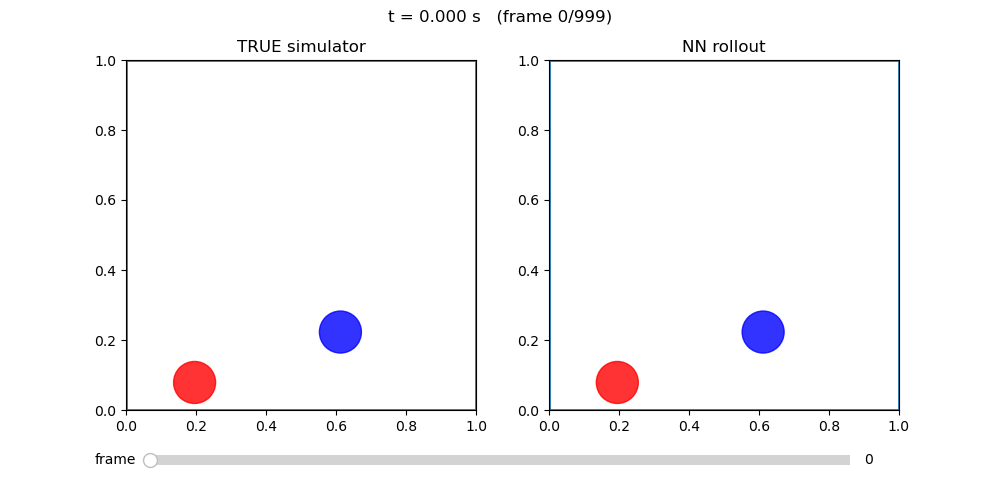

In [14]:
fig, slider = side_by_side_slider(
    pos_true,
    pos_pred,
    meta["radii"],
    float(meta["W"]),
    float(meta["H"]),
    float(meta["dt"]),
    T=1000
)

plt.show()



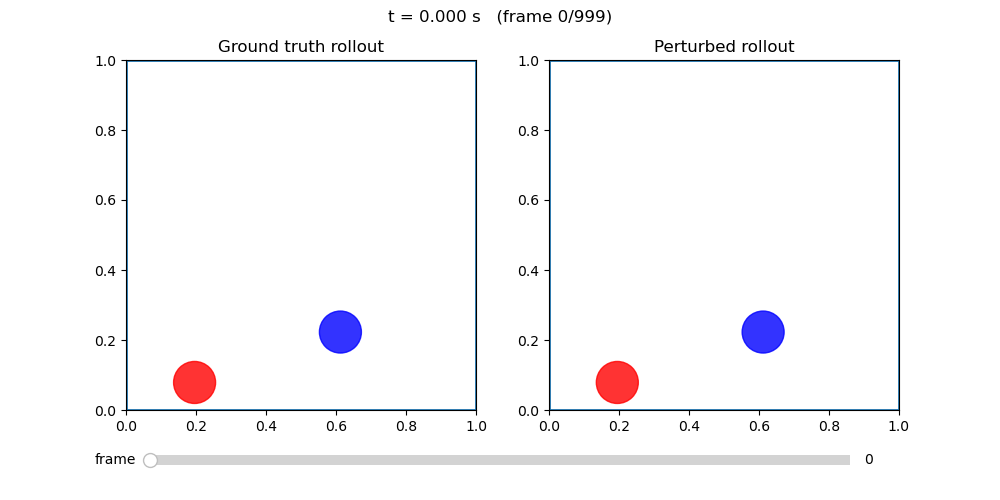

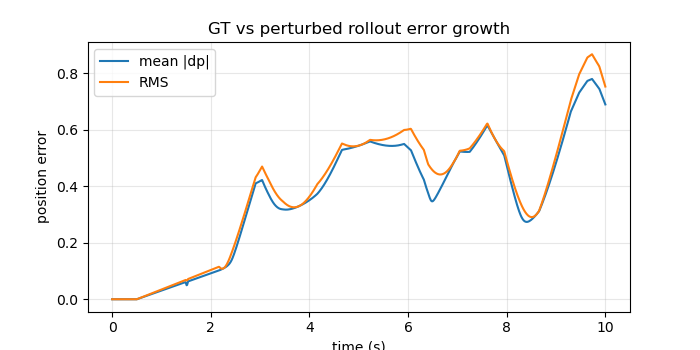

injections applied: 1
Try changing pert_cfg["sigma"], "inject_mode", and "inject_t" then rerun this cell.


In [27]:

# --- Perturbation experiment: GT vs perturbed simulator rollout ---
pert_cfg = {
    "steps": 1000,
    "sigma": 0.1,           # tune this
    "noise_seed": 7,
    "inject_mode": "t0",  # {"initial", "t0", "every_step", "every_k"}
    "inject_t": 50,         # used when inject_mode == "t0"
    "inject_every_k": 20,    # used when inject_mode == "every_k"
    "perturb_pos": False,
    "perturb_vel": True,
    "noise_kind": "gaussian",
    "speed_max": 0.7,
    "clamp_positions": True,
    "resolve_after_injection": False,
}

pert_results = paired_gt_perturbed_rollouts(
    meta=meta,
    pos0=pos0,
    vel0=vel0,
    **pert_cfg,
)

fig_pert, slider_pert = side_by_side_slider(
    pert_results["pos_true"],
    pert_results["pos_pert"],
    meta["radii"],
    float(meta["W"]),
    float(meta["H"]),
    float(meta["dt"]),
    T=pert_cfg["steps"],
    trail_len=500,
    left_title="Ground truth rollout",
    right_title="Perturbed rollout",
)
plt.show()

_ = plot_position_error_growth(
    pert_results["pos_true"],
    pert_results["pos_pert"],
    dt=float(meta["dt"]),
    logy=False,
)

print(f'injections applied: {int(pert_results["injected_mask"].sum())}')
print('Try changing pert_cfg["sigma"], "inject_mode", and "inject_t" then rerun this cell.')


In [26]:
from particle_nn_sim.rollout_eval import (
    collision_stats_from_rollout,
    plot_collision_stats_comparison,
)

dt = float(meta["dt"])
radii = np.asarray(meta["radii"], dtype=np.float32)
W = float(meta["W"])
H = float(meta["H"])

stats_gt = collision_stats_from_rollout(
    pert_results["pos_true"], pert_results["vel_true"], radii, W, H, dt
)
stats_pert = collision_stats_from_rollout(
    pert_results["pos_pert"], pert_results["vel_pert"], radii, W, H, dt
)

fig, axes = plot_collision_stats_comparison(
    stats_gt, stats_pert,
    labels=("Ground truth", "Perturbed"),
    bins=25,
)

print("GT:", stats_gt["collision_count"], stats_gt["collision_type_ratio"])
print("Pert:", stats_pert["collision_count"], stats_pert["collision_type_ratio"])


ImportError: cannot import name 'collision_stats_from_rollout' from 'particle_nn_sim.rollout_eval' (/Users/elnaz/Desktop/UCD/Research/research/research_project/particle_nn_sim_files/particle_nn_sim/rollout_eval.py)

In [92]:
torch.save(model.state_dict(), "model_final.pt")


In [94]:
import os
print(os.getcwd())


/Users/elnaz/Desktop/UCD/Research/research/research_project/particle_nn_sim_files


In [6]:
!ls

checkpoints            Figure 34.png          requirements.txt
curves_testmse_all.png model_final.pt         rollout.mp4
curves_testmse_col.png particle_nn_sim        run_experiment.py
curves_trainloss.png   README.md              run_expirement.ipynb


In [13]:
import torch, os

os.makedirs("checkpoints", exist_ok=True)

ckpt = {
    "epoch": 8000,                          # last finished epoch
    "model_state": model.state_dict(),
    "optimizer_state": opt.state_dict(),
    "history": hist,
    # (optional) anything else you need to reproduce training:
    # "lr": 1e-3,
    # "collision_weight": 1.0,
    # "weight_decay": 1e-6,
}

torch.save(ckpt, "checkpoints/ckpt_ep8000.pt")


In [ ]:
# --- Autoencoder Dynamics Model (residual target) ---
class AEDynamicsResidual(torch.nn.Module):
    def __init__(self, in_dim=12, latent_dim=32, pred_dim=8, hidden=128):
        super().__init__()
        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(in_dim, hidden), torch.nn.Tanh(),
            torch.nn.Linear(hidden, hidden), torch.nn.Tanh(),
            torch.nn.Linear(hidden, latent_dim)
        )
        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(latent_dim, hidden), torch.nn.Tanh(),
            torch.nn.Linear(hidden, hidden), torch.nn.Tanh(),
            torch.nn.Linear(hidden, in_dim)
        )
        self.pred_head = torch.nn.Sequential(
            torch.nn.Linear(latent_dim, hidden), torch.nn.Tanh(),
            torch.nn.Linear(hidden, pred_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_rec = self.decoder(z)
        y_pred = self.pred_head(z)
        return y_pred, x_rec


def train_ae_dynamics(model, train_loader, test_loader, device, epochs=200, lr=1e-3, recon_weight=0.1):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    mse = torch.nn.MSELoss()

    hist = {"train_total": [], "train_pred": [], "train_recon": [], "test_total": [], "test_pred": [], "test_recon": []}

    for ep in range(1, epochs + 1):
        model.train()
        tr_tot = tr_pred = tr_rec = 0.0
        n = 0
        for X, Y, *_ in train_loader:
            X = X.to(device)
            Y = Y.to(device)

            Yhat, Xrec = model(X)
            loss_pred = mse(Yhat, Y)
            loss_rec = mse(Xrec, X)
            loss = loss_pred + recon_weight * loss_rec

            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            b = X.shape[0]
            tr_tot += loss.item() * b
            tr_pred += loss_pred.item() * b
            tr_rec += loss_rec.item() * b
            n += b

        tr_tot /= max(n, 1)
        tr_pred /= max(n, 1)
        tr_rec /= max(n, 1)

        model.eval()
        te_tot = te_pred = te_rec = 0.0
        m = 0
        with torch.no_grad():
            for X, Y, *_ in test_loader:
                X = X.to(device)
                Y = Y.to(device)
                Yhat, Xrec = model(X)
                loss_pred = mse(Yhat, Y)
                loss_rec = mse(Xrec, X)
                loss = loss_pred + recon_weight * loss_rec

                b = X.shape[0]
                te_tot += loss.item() * b
                te_pred += loss_pred.item() * b
                te_rec += loss_rec.item() * b
                m += b

        te_tot /= max(m, 1)
        te_pred /= max(m, 1)
        te_rec /= max(m, 1)

        hist["train_total"].append(tr_tot)
        hist["train_pred"].append(tr_pred)
        hist["train_recon"].append(tr_rec)
        hist["test_total"].append(te_tot)
        hist["test_pred"].append(te_pred)
        hist["test_recon"].append(te_rec)

        if ep == 1 or ep % 20 == 0 or ep == epochs:
            print(f"AE epoch {ep:03d} | train_total={tr_tot:.6f} pred={tr_pred:.6f} rec={tr_rec:.6f} | "
                  f"test_total={te_tot:.6f} pred={te_pred:.6f} rec={te_rec:.6f}")

    return model, hist


@torch.no_grad()
def nn_rollout_ae_residual(model, pos0, vel0, radii, masses, steps,
                           x_mean, x_std, y_mean, y_std, device, dt):
    model.eval()
    pos_pred = np.zeros((steps+1, 2, 2), dtype=np.float32)
    vel_pred = np.zeros((steps+1, 2, 2), dtype=np.float32)
    pos_pred[0] = pos0.astype(np.float32)
    vel_pred[0] = vel0.astype(np.float32)

    pos_t = pos_pred[0].copy()
    vel_t = vel_pred[0].copy()

    for t in range(steps):
        x_raw = np.array([
            pos_t[0,0], pos_t[0,1], vel_t[0,0], vel_t[0,1], radii[0], masses[0],
            pos_t[1,0], pos_t[1,1], vel_t[1,0], vel_t[1,1], radii[1], masses[1],
        ], dtype=np.float32)

        x_n = ((x_raw[None,:] - x_mean) / x_std).astype(np.float32)
        x_torch = torch.from_numpy(x_n).to(device)

        resid_n, _ = model(x_torch)
        resid_n = resid_n.cpu().numpy()[0]
        resid = (resid_n * y_std[0]) + y_mean[0]

        pos_free = pos_t + vel_t * dt
        vel_free = vel_t
        y_free = np.array([
            pos_free[0,0], pos_free[0,1], vel_free[0,0], vel_free[0,1],
            pos_free[1,0], pos_free[1,1], vel_free[1,0], vel_free[1,1],
        ], dtype=np.float32)

        y_next = y_free + resid.astype(np.float32)
        pos_t = np.array([[y_next[0], y_next[1]], [y_next[4], y_next[5]]], dtype=np.float32)
        vel_t = np.array([[y_next[2], y_next[3]], [y_next[6], y_next[7]]], dtype=np.float32)

        pos_pred[t+1] = pos_t
        vel_pred[t+1] = vel_t

        if not (np.isfinite(pos_t).all() and np.isfinite(vel_t).all()):
            return pos_pred[:t+2], vel_pred[:t+2]

    return pos_pred, vel_pred


In [ ]:
# --- Train autoencoder dynamics model ---
ae_model = AEDynamicsResidual(in_dim=12, latent_dim=32, pred_dim=8, hidden=128)
ae_model, ae_hist = train_ae_dynamics(
    ae_model,
    train_loader,
    test_loader,
    device=device,
    epochs=300,
    lr=1e-3,
    recon_weight=0.1,
)

plt.figure(figsize=(8,4))
plt.plot(ae_hist["train_pred"], label="AE train pred loss")
plt.plot(ae_hist["test_pred"], label="AE test pred loss", linestyle="--")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.title("AE dynamics prediction loss")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [ ]:
# --- Rollout AE model and compare with GT ---
# reuse episode index from previous cells if available
if "e0" not in globals():
    e0 = test_eps[0]
if "pos0" not in globals() or "vel0" not in globals():
    pos0 = pos_all[e0, 0].astype(np.float32)
    vel0 = vel_all[e0, 0].astype(np.float32)

steps_eval = 1000

sim_true = ParticleSim2D(
    W=float(meta["W"]),
    H=float(meta["H"]),
    radii=meta["radii"],
    masses=meta["masses"],
    restitution=float(meta["restitution"]),
    seed=123,
)
sim_true.reset(pos0, vel0)
pos_true_ae, vel_true_ae = sim_true.rollout(dt=float(meta["dt"]), steps=steps_eval)

pos_pred_ae, vel_pred_ae = nn_rollout_ae_residual(
    ae_model,
    pos0,
    vel0,
    radii=np.asarray(meta["radii"], dtype=np.float32),
    masses=np.asarray(meta["masses"], dtype=np.float32),
    steps=steps_eval,
    x_mean=x_mean,
    x_std=x_std,
    y_mean=y_mean,
    y_std=y_std,
    device=device,
    dt=float(meta["dt"]),
)

plot_rollout_error(pos_true_ae, pos_pred_ae, dt=float(meta["dt"]))

fig_ae, slider_ae = side_by_side_slider(
    pos_true_ae,
    pos_pred_ae,
    meta["radii"],
    float(meta["W"]),
    float(meta["H"]),
    float(meta["dt"]),
    T=min(len(pos_true_ae), len(pos_pred_ae)),
)
plt.show()


In [24]:
# === One-particle-in-box setup: ground truth + data generation ===

def sample_init_1p(W, H, radius, speed_max=0.7, seed=None):
    rng = np.random.default_rng(seed)
    pos = np.array([
        rng.uniform(radius, W - radius),
        rng.uniform(radius, H - radius),
    ], dtype=np.float32)
    theta = rng.uniform(0, 2*np.pi)
    mag = rng.uniform(0.0, speed_max)
    vel = np.array([mag*np.cos(theta), mag*np.sin(theta)], dtype=np.float32)
    return pos[None, :], vel[None, :]


def collect_episodes_1p(sim, E=300, steps=800, dt=0.01, speed_max=0.7, seed=0):
    rng = np.random.default_rng(seed)
    T = steps + 1

    pos_all = np.zeros((E, T, 1, 2), dtype=np.float32)
    vel_all = np.zeros((E, T, 1, 2), dtype=np.float32)
    coll_all = np.zeros((E, T - 1), dtype=np.uint8)

    r = float(sim.radii[0])
    W, H = float(sim.W), float(sim.H)

    for e in range(E):
        pos0, vel0 = sample_init_1p(W, H, r, speed_max=speed_max, seed=rng.integers(1e9))
        sim.reset(pos0, vel0)

        pos_traj, vel_traj = sim.rollout(dt=dt, steps=steps)
        pos_traj = pos_traj.astype(np.float32)
        vel_traj = vel_traj.astype(np.float32)

        # wall-collision flag from velocity sign flip between frames
        vx_prev = vel_traj[:-1, 0, 0]
        vx_next = vel_traj[1:, 0, 0]
        vy_prev = vel_traj[:-1, 0, 1]
        vy_next = vel_traj[1:, 0, 1]
        wall_hit = (vx_prev * vx_next < 0) | (vy_prev * vy_next < 0)

        pos_all[e] = pos_traj
        vel_all[e] = vel_traj
        coll_all[e] = wall_hit.astype(np.uint8)

    meta_1p = {
        "dt": np.float32(dt),
        "W": np.float32(sim.W),
        "H": np.float32(sim.H),
        "radii": sim.radii.astype(np.float32),
        "masses": sim.masses.astype(np.float32),
        "restitution": np.float32(sim.restitution),
    }
    return pos_all, vel_all, coll_all, meta_1p


def episodes_to_XY_residual_1p(pos_all, vel_all, coll_all, meta, episode_indices):
    dt = float(meta["dt"])
    r = float(np.asarray(meta["radii"])[0])
    m = float(np.asarray(meta["masses"])[0])

    X_list, Y_list, C_list = [], [], []
    for e in episode_indices:
        pos = pos_all[e]  # (T,1,2)
        vel = vel_all[e]  # (T,1,2)
        C = coll_all[e]   # (T-1,)

        pos_t = pos[:-1, 0, :]
        vel_t = vel[:-1, 0, :]
        pos_n = pos[1:, 0, :]
        vel_n = vel[1:, 0, :]

        Tm1 = pos_t.shape[0]
        X = np.zeros((Tm1, 6), dtype=np.float32)
        Y_next = np.zeros((Tm1, 4), dtype=np.float32)
        Y_free = np.zeros((Tm1, 4), dtype=np.float32)

        X[:, 0:2] = pos_t
        X[:, 2:4] = vel_t
        X[:, 4] = r
        X[:, 5] = m

        Y_next[:, 0:2] = pos_n
        Y_next[:, 2:4] = vel_n

        pos_free = pos_t + vel_t * dt
        vel_free = vel_t
        Y_free[:, 0:2] = pos_free
        Y_free[:, 2:4] = vel_free

        Y_resid = (Y_next - Y_free).astype(np.float32)

        X_list.append(X)
        Y_list.append(Y_resid)
        C_list.append(C.astype(np.uint8))

    return np.concatenate(X_list, axis=0), np.concatenate(Y_list, axis=0), np.concatenate(C_list, axis=0)


In [25]:
# === Build one-particle dataset/loaders ===
sim_1p = ParticleSim2D(
    W=1.0,
    H=1.0,
    radii=[0.06],
    masses=[1.0],
    restitution=1.0,
    seed=7,
)

pos_all_1p, vel_all_1p, coll_all_1p, meta_1p = collect_episodes_1p(
    sim_1p,
    E=300,
    steps=800,
    dt=0.01,
    speed_max=0.7,
    seed=0,
)

E1 = pos_all_1p.shape[0]
idx1 = np.arange(E1)
n_train1 = int(0.8 * E1)
train_eps1 = idx1[:n_train1]
test_eps1 = idx1[n_train1:]

Xtr1, Ytr1, Ctr1 = episodes_to_XY_residual_1p(pos_all_1p, vel_all_1p, coll_all_1p, meta_1p, train_eps1)
Xte1, Yte1, Cte1 = episodes_to_XY_residual_1p(pos_all_1p, vel_all_1p, coll_all_1p, meta_1p, test_eps1)

x_mean1, x_std1 = fit_standardizer(Xtr1)
y_mean1, y_std1 = fit_standardizer(Ytr1)

Xtr1_n = apply_standardizer(Xtr1, x_mean1, x_std1)
Ytr1_n = apply_standardizer(Ytr1, y_mean1, y_std1)
Xte1_n = apply_standardizer(Xte1, x_mean1, x_std1)
Yte1_n = apply_standardizer(Yte1, y_mean1, y_std1)

train_loader_1p = DataLoader(StepDataset(Xtr1_n, Ytr1_n, Ctr1), batch_size=512, shuffle=True, drop_last=True)
test_loader_1p = DataLoader(StepDataset(Xte1_n, Yte1_n, Cte1), batch_size=512, shuffle=False)

print('1p train samples:', Xtr1_n.shape[0], '| test samples:', Xte1_n.shape[0])
print('X dim:', Xtr1_n.shape[1], '| Y dim:', Ytr1_n.shape[1], '| collision frac train:', float(Ctr1.mean()))


1p train samples: 192000 | test samples: 48000
X dim: 6 | Y dim: 4 | collision frac train: 0.005130208333333333


Training 1p MLP
Epoch 001 | train_loss=0.979514 | test_mse=0.695649 | test_collision=138.418587 | test_noncollision=0.012268 (n_col=237, n_noncol=47763)
Epoch 002 | train_loss=0.959384 | test_mse=0.690028 | test_collision=136.977494 | test_noncollision=0.013770 (n_col=237, n_noncol=47763)
Epoch 003 | train_loss=0.943516 | test_mse=0.680300 | test_collision=131.736449 | test_noncollision=0.029999 (n_col=237, n_noncol=47763)
Epoch 004 | train_loss=0.927636 | test_mse=0.657797 | test_collision=127.582396 | test_noncollision=0.027997 (n_col=237, n_noncol=47763)
Epoch 005 | train_loss=0.912760 | test_mse=0.658151 | test_collision=130.459751 | test_noncollision=0.014076 (n_col=237, n_noncol=47763)
Epoch 006 | train_loss=0.901152 | test_mse=0.638228 | test_collision=122.946978 | test_noncollision=0.031332 (n_col=237, n_noncol=47763)
Epoch 007 | train_loss=0.890800 | test_mse=0.636807 | test_collision=121.339231 | test_noncollision=0.037882 (n_col=237, n_noncol=47763)
Epoch 008 | train_loss=0.

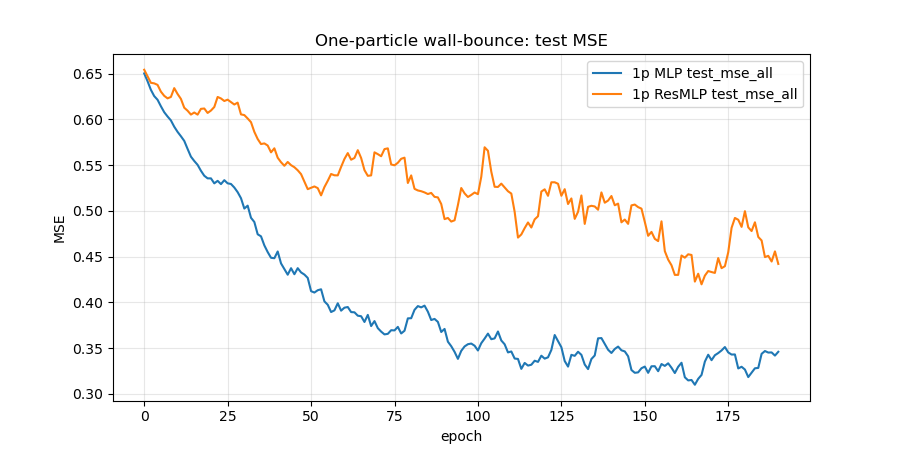

In [28]:
# === Train existing models on one-particle data (MLP + ResMLP) ===
model_1p_mlp = MLP(in_dim=6, hidden=128, out_dim=4, dropout=0.05)
model_1p_res = ResMLP(in_dim=6, hidden=128, out_dim=4, blocks=3, dropout=0.05)

print("\nTraining 1p MLP")
stats_1p_mlp, hist_1p_mlp, _ = train(
    model_1p_mlp,
    train_loader_1p,
    test_loader_1p,
    device=device,
    epochs=200,
    lr=1e-3,
    collision_weight=1.0,
    weight_decay=1e-6,
)
print('1p MLP FINAL TEST:', stats_1p_mlp)

print("\nTraining 1p ResMLP")
stats_1p_res, hist_1p_res, _ = train(
    model_1p_res,
    train_loader_1p,
    test_loader_1p,
    device=device,
    epochs=200,
    lr=1e-3,
    collision_weight=1.0,
    weight_decay=1e-6,
)
print('1p ResMLP FINAL TEST:', stats_1p_res)


def _smooth(x, k=10):
    x = np.asarray(x, dtype=float)
    if len(x) < k:
        return x
    return np.convolve(x, np.ones(k)/k, mode='valid')

plt.figure(figsize=(9, 4.5))
plt.plot(_smooth(hist_1p_mlp['test_mse_all']), label='1p MLP test_mse_all')
plt.plot(_smooth(hist_1p_res['test_mse_all']), label='1p ResMLP test_mse_all')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.title('One-particle wall-bounce: test MSE')
plt.grid(alpha=0.3)
plt.legend()
plt.show()



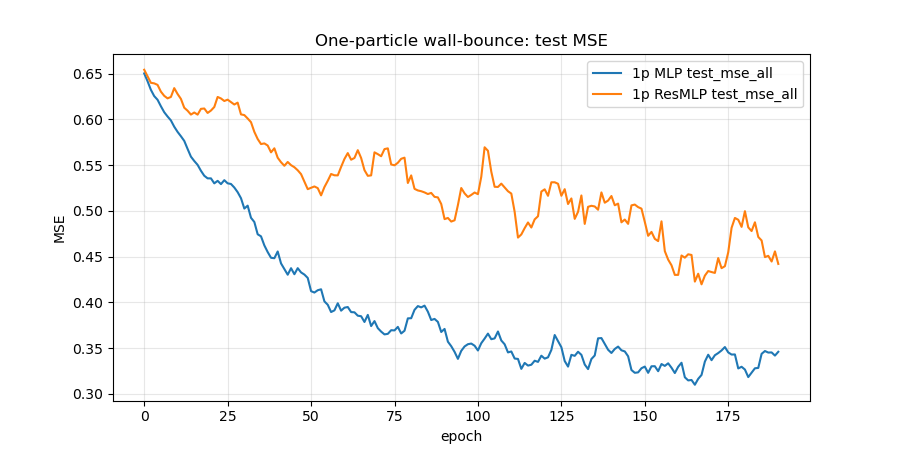

In [30]:
def _smooth(x, k=10):
    x = np.asarray(x, dtype=float)
    if len(x) < k:
        return x
    return np.convolve(x, np.ones(k)/k, mode='valid')

plt.figure(figsize=(9, 4.5))
plt.plot(_smooth(hist_1p_mlp['test_mse_all']), label='1p MLP test_mse_all')
plt.plot(_smooth(hist_1p_res['test_mse_all']), label='1p ResMLP test_mse_all')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.title('One-particle wall-bounce: test MSE')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [31]:
import torch, json, numpy as np

ckpt = {
    "model_state_dict": model_1p_res.state_dict(),   # or model_1p_mlp
    "model_name": "ResMLP",
    "model_kwargs": {"in_dim": 6, "hidden": 128, "out_dim": 4, "blocks": 3, "dropout": 0.05},
    "hist": hist_1p_res,
    "x_mean": x_mean1,
    "x_std": x_std1,
    "y_mean": y_mean1,
    "y_std": y_std1,
    "meta": meta_1p,
}

torch.save(ckpt, "model_1p_residual.pt")
print("saved model_1p_residual.pt")


saved model_1p_residual.pt


In [ ]:
# === One-particle GT vs model rollout (side-by-side slider) ===
@torch.no_grad()
def nn_rollout_residual_1p(model, pos0, vel0, radius, mass, steps,
                           x_mean, x_std, y_mean, y_std, device, dt):
    model.eval()
    pos_pred = np.zeros((steps + 1, 1, 2), dtype=np.float32)
    vel_pred = np.zeros((steps + 1, 1, 2), dtype=np.float32)
    pos_pred[0] = pos0.astype(np.float32)
    vel_pred[0] = vel0.astype(np.float32)

    pos_t = pos_pred[0, 0].copy()
    vel_t = vel_pred[0, 0].copy()

    for t in range(steps):
        x_raw = np.array([
            pos_t[0], pos_t[1], vel_t[0], vel_t[1], float(radius), float(mass)
        ], dtype=np.float32)
        x_n = ((x_raw[None, :] - x_mean) / x_std).astype(np.float32)

        y_n = model(torch.from_numpy(x_n).to(device)).cpu().numpy()[0]
        y_resid = (y_n * y_std[0]) + y_mean[0]  # (4,)

        pos_free = pos_t + vel_t * dt
        vel_free = vel_t
        y_free = np.array([pos_free[0], pos_free[1], vel_free[0], vel_free[1]], dtype=np.float32)

        y_next = y_free + y_resid.astype(np.float32)
        pos_t = y_next[0:2]
        vel_t = y_next[2:4]

        pos_pred[t + 1, 0] = pos_t
        vel_pred[t + 1, 0] = vel_t

    return pos_pred, vel_pred


# pick a test episode
e1 = test_eps1[0]
pos0_1p = pos_all_1p[e1, 0].astype(np.float32)
vel0_1p = vel_all_1p[e1, 0].astype(np.float32)
steps_1p = 800

# GT rollout
sim_gt_1p = ParticleSim2D(
    W=float(meta_1p['W']),
    H=float(meta_1p['H']),
    radii=meta_1p['radii'],
    masses=meta_1p['masses'],
    restitution=float(meta_1p['restitution']),
    seed=123,
)
sim_gt_1p.reset(pos0_1p, vel0_1p)
pos_true_1p, vel_true_1p = sim_gt_1p.rollout(dt=float(meta_1p['dt']), steps=steps_1p)

# model rollout (ResMLP)
pos_pred_1p, vel_pred_1p = nn_rollout_residual_1p(
    model_1p_res,
    pos0_1p,
    vel0_1p,
    radius=float(meta_1p['radii'][0]),
    mass=float(meta_1p['masses'][0]),
    steps=steps_1p,
    x_mean=x_mean1,
    x_std=x_std1,
    y_mean=y_mean1,
    y_std=y_std1,
    device=device,
    dt=float(meta_1p['dt']),
)

# error plot
err_1p = np.linalg.norm(pos_true_1p[:, 0, :] - pos_pred_1p[:, 0, :], axis=1)
t_1p = np.arange(len(err_1p)) * float(meta_1p['dt'])
plt.figure(figsize=(7, 3.5))
plt.plot(t_1p, err_1p)
plt.xlabel('time (s)')
plt.ylabel('position error')
plt.title('1p GT vs ResMLP rollout error')
plt.grid(alpha=0.3)
plt.show()

fig_1p, slider_1p = side_by_side_slider(
    pos_true_1p,
    pos_pred_1p,
    meta_1p['radii'],
    float(meta_1p['W']),
    float(meta_1p['H']),
    float(meta_1p['dt']),
    T=steps_1p,
)
plt.show()

